# RSA Regularization Main Figure

This notebook produces a single streamlined publication-style figure from the notebook 12 sweep.

Core message:
1. Sequence-level classification is largely unchanged across `lambda_rsa`.
2. Pooling-attention epitope residue alignment does not show a clear improvement.


In [19]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing pyproject.toml")


repo_root = find_repo_root(Path.cwd().resolve())
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

results_dir = repo_root / "results" / "rsa_regularization"
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_csv(results_dir / "sweep_summary.csv").sort_values("lambda_rsa").reset_index(drop=True)
summary_df["lambda_label"] = summary_df["lambda_rsa"].map(lambda value: f"{value:g}")
summary_df["x"] = np.arange(len(summary_df))

baseline = summary_df.loc[summary_df["lambda_rsa"].eq(0.0)].iloc[0]
for metric in ["test_mcc", "test_auroc", "test_f1", "test_accuracy", "test_precision", "test_recall", "residue_auroc", "residue_auprc", "residue_precision_at_k"]:
    summary_df[f"delta_{metric}"] = summary_df[metric] - baseline[metric]


def lambda_dir_name(lambda_value: float) -> str:
    return f"lambda_{int(lambda_value)}" if float(lambda_value).is_integer() else f"lambda_{str(lambda_value).replace('.', 'p')}"


residue_ci_rows = []
probe_frames = []
for row in summary_df.itertuples(index=False):
    metrics_path = results_dir / lambda_dir_name(row.lambda_rsa) / "metrics.json"
    with metrics_path.open() as handle:
        metrics_payload = json.load(handle)
    residue_summary = metrics_payload["residue_summary"]
    residue_metric_map = {
        "Pooling attention AUROC": ("auroc_mean", "auroc_ci_low", "auroc_ci_high", float(baseline["residue_auroc"])),
        "Pooling attention AUPRC": ("auprc_mean", "auprc_ci_low", "auprc_ci_high", float(baseline["residue_auprc"])),
        "Pooling attention precision@k": ("precision_at_k_mean", "precision_at_k_ci_low", "precision_at_k_ci_high", float(baseline["residue_precision_at_k"])),
    }
    for metric_label, (mean_key, low_key, high_key, baseline_value) in residue_metric_map.items():
        residue_ci_rows.append({
            "lambda_rsa": row.lambda_rsa,
            "x": row.x,
            "metric": metric_label,
            "delta_mean": residue_summary[mean_key] - baseline_value,
            "delta_low": residue_summary[low_key] - baseline_value,
            "delta_high": residue_summary[high_key] - baseline_value,
        })
    probe_path = results_dir / lambda_dir_name(row.lambda_rsa) / "probing_rows.csv"
    probe_df = pd.read_csv(probe_path)
    probe_df["lambda_rsa"] = row.lambda_rsa
    probe_frames.append(probe_df)

residue_ci_df = pd.DataFrame(residue_ci_rows)
probe_df = pd.concat(probe_frames, ignore_index=True)

loss_rows = []
for row in summary_df.itertuples(index=False):
    metrics_path = results_dir / lambda_dir_name(row.lambda_rsa) / "metrics.json"
    with metrics_path.open() as handle:
        metrics_payload = json.load(handle)
    for split_name, loss_key in [("validation", "validation_loss"), ("test", "test_loss")]:
        cls_loss = float(metrics_payload[loss_key]["cls_loss"])
        rsa_loss = metrics_payload[loss_key]["rsa_loss"]
        weighted_rsa_loss = 0.0 if rsa_loss is None else float(row.lambda_rsa) * float(rsa_loss)
        total_loss = float(metrics_payload[loss_key]["total_loss"])
        loss_rows.append({
            "lambda_rsa": row.lambda_rsa,
            "split": split_name,
            "classification_loss": cls_loss,
            "rsa_loss_raw": np.nan if rsa_loss is None else float(rsa_loss),
            "rsa_loss_weighted": weighted_rsa_loss,
            "rsa_vs_cls_ratio": weighted_rsa_loss / cls_loss if cls_loss else np.nan,
            "rsa_fraction_of_total": weighted_rsa_loss / total_loss if total_loss else np.nan,
        })
loss_df = pd.DataFrame(loss_rows)
test_loss_df = loss_df.loc[loss_df["split"].eq("test")].sort_values("lambda_rsa").reset_index(drop=True).copy()
test_loss_df = test_loss_df.merge(summary_df.loc[:, ["lambda_rsa", "x"]], on="lambda_rsa", how="left")
test_loss_df["rsa_fraction_pct"] = 100.0 * test_loss_df["rsa_fraction_of_total"]


def paired_sign_flip_pvalue(differences: np.ndarray, n_resamples: int = 50000, seed: int = 0) -> float:
    differences = np.asarray(differences, dtype=float)
    differences = differences[~np.isnan(differences)]
    differences = differences[differences != 0]
    if differences.size == 0:
        return 1.0
    observed = abs(differences.mean())
    rng = np.random.default_rng(seed)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_resamples, differences.size))
    null_means = np.abs((signs * differences).mean(axis=1))
    return float((np.count_nonzero(null_means >= observed) + 1) / (n_resamples + 1))


def benjamini_hochberg(pvalues: list[float]) -> np.ndarray:
    pvalues = np.asarray(pvalues, dtype=float)
    order = np.argsort(pvalues)
    ranked = pvalues[order]
    n = ranked.size
    adjusted = np.empty(n, dtype=float)
    running = 1.0
    for idx in range(n - 1, -1, -1):
        rank = idx + 1
        running = min(running, ranked[idx] * n / rank)
        adjusted[idx] = running
    restored = np.empty(n, dtype=float)
    restored[order] = adjusted
    return restored

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

summary_df[["lambda_rsa", "test_mcc", "test_auroc", "test_f1", "test_accuracy", "test_precision", "test_recall", "residue_auroc", "residue_auprc", "residue_precision_at_k"]].round(4)

,lambda_rsa,test_mcc,test_auroc,test_f1,test_accuracy,test_precision,test_recall,residue_auroc,residue_auprc,residue_precision_at_k
0,0.0,0.8336,0.9699,0.9160,0.9165,0.8996,0.9330,0.4677,0.2529,0.2163
1,0.1,0.8293,0.9693,0.9139,0.9143,0.8968,0.9315,0.4679,0.2527,0.2165
2,0.5,0.8474,0.9697,0.9218,0.9237,0.9225,0.9211,0.4660,0.2519,0.2148
3,1.0,0.8390,0.9705,0.9184,0.9194,0.9071,0.9301,0.4667,0.2517,0.2188
4,5.0,0.8460,0.9694,0.9212,0.9230,0.9199,0.9226,0.4570,0.2474,0.2146


## Loss Contribution Check

The optimization target is `total_loss = cls_loss + lambda_rsa * rsa_loss`, so the important comparison is the classification loss versus the weighted RSA term. This compact table shows that the classification head loss dominates throughout the sweep.


In [20]:
loss_df.loc[:, [
    "lambda_rsa",
    "split",
    "classification_loss",
    "rsa_loss_raw",
    "rsa_loss_weighted",
    "rsa_vs_cls_ratio",
    "rsa_fraction_of_total",
]].round(4)

,lambda_rsa,split,classification_loss,rsa_loss_raw,rsa_loss_weighted,rsa_vs_cls_ratio,rsa_fraction_of_total
0,0.0,validation,0.1926,NaN,0.0000,0.0000,0.0000
1,0.0,test,0.2322,NaN,0.0000,0.0000,0.0000
2,0.1,validation,0.1925,0.0029,0.0003,0.0015,0.0015
3,0.1,test,0.2352,0.0029,0.0003,0.0012,0.0012
4,0.5,validation,0.1930,0.0029,0.0014,0.0075,0.0074
5,0.5,test,0.2394,0.0029,0.0015,0.0061,0.0061
6,1.0,validation,0.1959,0.0028,0.0028,0.0145,0.0142
7,1.0,test,0.2284,0.0029,0.0029,0.0125,0.0124
8,5.0,validation,0.2005,0.0027,0.0133,0.0665,0.0624
9,5.0,test,0.2375,0.0027,0.0135,0.0567,0.0536


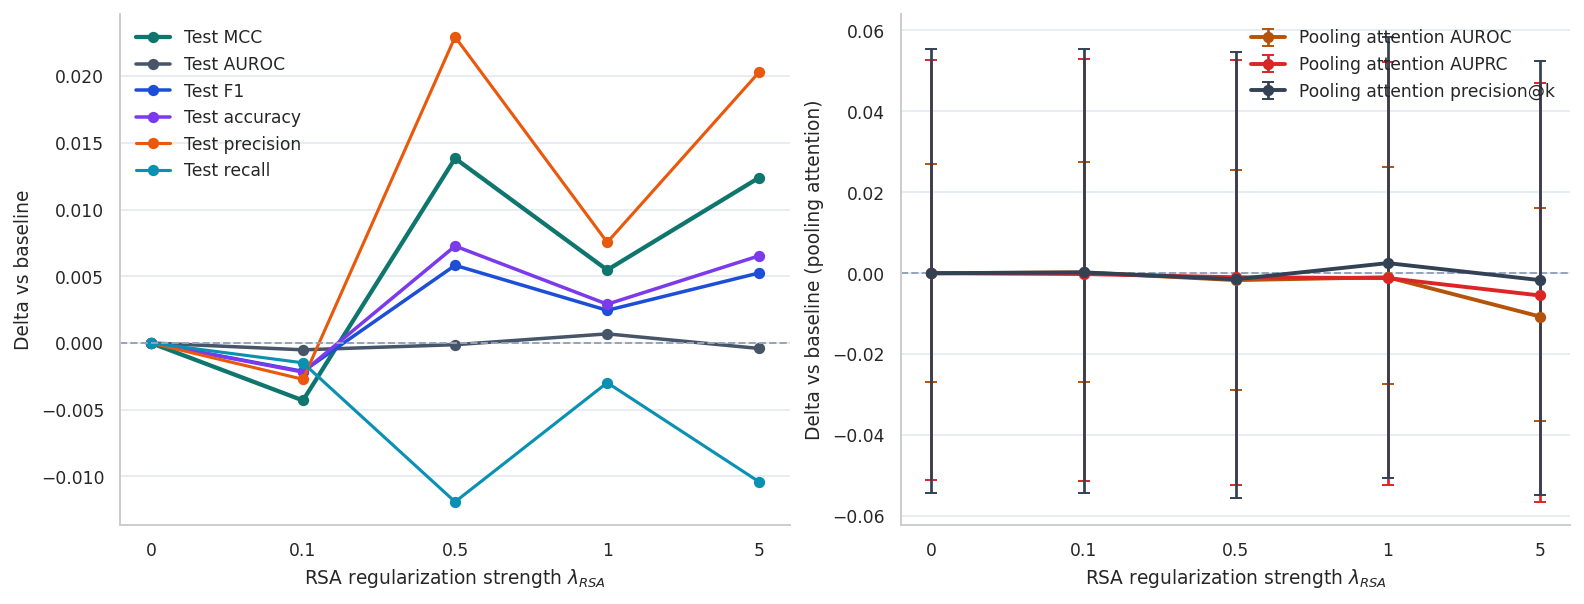

(PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/rsa_regularization/figures/rsa_regularization_main_message.png'),
 PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/rsa_regularization/figures/rsa_regularization_main_message.pdf'))

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), constrained_layout=True)

axes[0].plot(summary_df["x"], summary_df["delta_test_mcc"], marker="o", linewidth=2.2, color="#0f766e", label="Test MCC")
axes[0].plot(summary_df["x"], summary_df["delta_test_auroc"], marker="o", linewidth=1.8, color="#475569", label="Test AUROC")
axes[0].plot(summary_df["x"], summary_df["delta_test_f1"], marker="o", linewidth=1.8, color="#1d4ed8", label="Test F1")
axes[0].plot(summary_df["x"], summary_df["delta_test_accuracy"], marker="o", linewidth=1.8, color="#7c3aed", label="Test accuracy")
axes[0].plot(summary_df["x"], summary_df["delta_test_precision"], marker="o", linewidth=1.6, color="#ea580c", label="Test precision")
axes[0].plot(summary_df["x"], summary_df["delta_test_recall"], marker="o", linewidth=1.6, color="#0891b2", label="Test recall")
axes[0].axhline(0, color="#94a3b8", linewidth=1, linestyle="--")
axes[0].set_xlabel(r"RSA regularization strength $\lambda_{RSA}$")
axes[0].set_ylabel("Delta vs baseline")
axes[0].set_xticks(summary_df["x"], summary_df["lambda_label"])
axes[0].legend(frameon=False, loc="upper left")

residue_styles = {
    "Pooling attention AUROC": "#b45309",
    "Pooling attention AUPRC": "#dc2626",
    "Pooling attention precision@k": "#334155",
}
for metric_label, color in residue_styles.items():
    metric_df = residue_ci_df.loc[residue_ci_df["metric"].eq(metric_label)]
    yerr = np.vstack([
        metric_df["delta_mean"] - metric_df["delta_low"],
        metric_df["delta_high"] - metric_df["delta_mean"],
    ])
    axes[1].errorbar(
        metric_df["x"],
        metric_df["delta_mean"],
        yerr=yerr,
        marker="o",
        linewidth=2.0,
        elinewidth=1.4,
        capsize=3,
        color=color,
        ecolor=color,
        label=metric_label,
        zorder=3,
    )
axes[1].axhline(0, color="#94a3b8", linewidth=1, linestyle="--")
axes[1].set_xlabel(r"RSA regularization strength $\lambda_{RSA}$")
axes[1].set_ylabel("Delta vs baseline (pooling attention)")
axes[1].set_xticks(summary_df["x"], summary_df["lambda_label"])
axes[1].legend(frameon=False, loc="upper right")

for ax in axes:
    ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
    ax.grid(False, axis="x")

output_png = figures_dir / "rsa_regularization_main_message.png"
output_pdf = figures_dir / "rsa_regularization_main_message.pdf"
fig.savefig(output_png, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
plt.show()

output_png, output_pdf

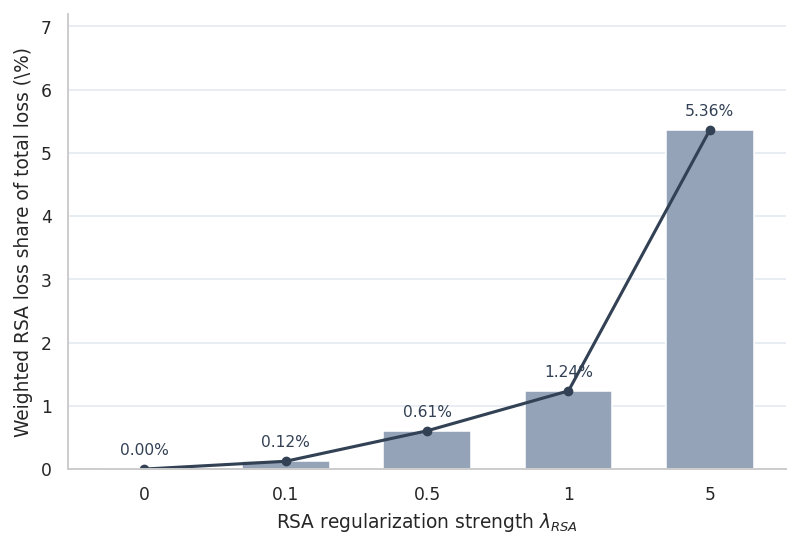

(PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/rsa_regularization/figures/rsa_regularization_loss_decomposition.png'),
 PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/rsa_regularization/figures/rsa_regularization_loss_decomposition.pdf'))

In [22]:
fig, ax = plt.subplots(figsize=(5.6, 3.8), constrained_layout=True)

ax.bar(test_loss_df["x"], test_loss_df["rsa_fraction_pct"], color="#94a3b8", width=0.62)
ax.plot(test_loss_df["x"], test_loss_df["rsa_fraction_pct"], color="#334155", linewidth=1.6, marker="o", markersize=4)
ax.set_xlabel(r"RSA regularization strength $\lambda_{RSA}$")
ax.set_ylabel(r"Weighted RSA loss share of total loss (\%)")
ax.set_xticks(test_loss_df["x"], test_loss_df["lambda_rsa"].map(lambda value: f"{value:g}"))
ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
ax.grid(False, axis="x")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for x_value, pct_value in zip(test_loss_df["x"], test_loss_df["rsa_fraction_pct"]):
    ax.text(x_value, pct_value + 0.18, f"{pct_value:.2f}%", ha="center", va="bottom", fontsize=8, color="#334155")
ax.set_ylim(0, max(7.2, float(test_loss_df["rsa_fraction_pct"].max()) + 0.9))

loss_png = figures_dir / "rsa_regularization_loss_decomposition.png"
loss_pdf = figures_dir / "rsa_regularization_loss_decomposition.pdf"
fig.savefig(loss_png, bbox_inches="tight")
fig.savefig(loss_pdf, bbox_inches="tight")
plt.show()

loss_png, loss_pdf

Suggested caption: RSA regularization across `lambda_rsa` values from `0.1` to `5.0` leaves sequence-level allergen classification nearly unchanged, while pooling-attention epitope residue alignment remains flat with overlapping confidence intervals. The loss decomposition table shows that `cls_loss` dominates the optimization objective throughout the sweep, with `lambda_rsa * rsa_loss` contributing only a small fraction of total loss, providing a mechanistic explanation for why RSA regularization fails to meaningfully shift the learned pooling-attention alignment signal in the current frozen ESM-2 baseline.
